# Experiment-level parameter recovery audit

Question: does the current browser adaptive workflow recover known simulated participants, and how do Stan MI ADO, Stan random designs, and Quest+ compare on the same experiment grid?

This notebook drives the actual jsPsych experiment page in `simulate=data-only` mode. It is an explainer/audit template, not CI and not a definitive efficiency study. The table used for analysis is normalized to one row per experiment, model, strategy label, simulation profile, seed, trial, and parameter so the same notebook shape can cover future models with different parameter counts.

The comparison arms answer slightly different questions. Stan MI ADO is the main workflow: Stan/WASM posterior updates with mutual-information design selection. Stan random keeps the same Stan/WASM posterior updates but samples designs randomly from the same grid, isolating the value of adaptive design selection. Quest+ is a separate discrete-grid adaptive controller and posterior, so it is an alternative-controller benchmark rather than a pure design-strategy ablation.

The notebook lives under `examples/parameter_recovery/` because the workflow is intended to be reused across experiments. By default, the parameter cell runs the delay-discounting example. To run another experiment, execute the notebook with papermill and set `SETTINGS_PATH` to a JSON settings file such as `examples/parameter_recovery/line_length_discrimination_settings.json`.


In [1]:
# Parameters
SETTINGS_PATH = None
EXPERIMENT_PATH = "experiments/delay_discounting/index.html"
MODEL_ID = "hyperbolic"
CHOICE_TASK_FIELD = "task"
CHOICE_TASK = "delay_discounting"
TRIAL_NUMBER_FIELD = "trial_number"
DESIGN_FIELDS = ["r_ss", "t_ss", "r_ll", "t_ll"]
RUN_SPECS = [
    {"strategy": "ado", "query": {"controller": "stan", "strategy": "ado"}},
    {"strategy": "random", "query": {"controller": "stan", "strategy": "random"}},
    {"strategy": "quest_plus", "query": {"controller": "quest_plus"}},
]
STRATEGIES = [spec["strategy"] for spec in RUN_SPECS]
SIMULATION_PROFILES = [
    {"profile_id": "k_1e-4", "sweep": "k", "params": {"k": 1e-4, "tau": 2.5}},
    {"profile_id": "k_1e-3", "sweep": "k", "params": {"k": 1e-3, "tau": 2.5}},
    {"profile_id": "k_1e-2", "sweep": "k", "params": {"k": 1e-2, "tau": 2.5}},
    {"profile_id": "tau_0.5", "sweep": "tau", "params": {"k": 5e-3, "tau": 0.5}},
    {"profile_id": "tau_2.5", "sweep": "tau", "params": {"k": 5e-3, "tau": 2.5}},
    {"profile_id": "tau_5.0", "sweep": "tau", "params": {"k": 5e-3, "tau": 5.0}},
]
SEEDS = [101, 102, 103, 104, 105]
PARAMETERS = [
    {"name": "k", "scale": "log10", "label": "Discount rate k"},
    {"name": "tau", "scale": "linear", "label": "Choice sensitivity tau"},
]
SELECTED_PARAMETERS = ["k", "tau"]
RUN_QUICK = False
DIRECTIONAL_CHECKS = []
INCLUDE_RAW = False


In [2]:
# Parameters
SETTINGS_PATH = "examples/parameter_recovery/line_length_discrimination_settings.json"


## Run the browser audit

The helper starts a local static server, injects `window.__JSPSYCH_ADO_RUN_CONFIG__`, opens the experiment with `simulate=data-only`, and reads the displayed jsPsych JSON. The notebook calls the helper in a subprocess so Playwright runs outside the notebook kernel event loop.

In [3]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / EXPERIMENT_PATH).exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

HELPER_PATH = REPO_ROOT / "examples/parameter_recovery/parameter_recovery_browser.py"
if not HELPER_PATH.exists():
    raise FileNotFoundError(HELPER_PATH)

if SETTINGS_PATH:
    settings_path = Path(SETTINGS_PATH)
    if not settings_path.is_absolute():
        settings_path = REPO_ROOT / settings_path
    external_settings = json.loads(settings_path.read_text())
    EXPERIMENT_PATH = external_settings.get("experiment_path", EXPERIMENT_PATH)
    MODEL_ID = external_settings.get("model_id", MODEL_ID)
    CHOICE_TASK_FIELD = external_settings.get("choice_task_field", CHOICE_TASK_FIELD)
    CHOICE_TASK = external_settings.get("choice_task", CHOICE_TASK)
    TRIAL_NUMBER_FIELD = external_settings.get("trial_number_field", TRIAL_NUMBER_FIELD)
    DESIGN_FIELDS = external_settings.get("design_fields", DESIGN_FIELDS)
    RUN_SPECS = external_settings.get("run_specs", RUN_SPECS)
    STRATEGIES = [spec["strategy"] for spec in RUN_SPECS]
    SIMULATION_PROFILES = external_settings.get("simulation_profiles", SIMULATION_PROFILES)
    SEEDS = external_settings.get("seeds", SEEDS)
    PARAMETERS = external_settings.get("parameters", PARAMETERS)
    SELECTED_PARAMETERS = external_settings.get("selected_parameters", [param["name"] for param in PARAMETERS])
    DIRECTIONAL_CHECKS = external_settings.get("directional_checks", DIRECTIONAL_CHECKS)

profiles = SIMULATION_PROFILES[:1] if RUN_QUICK else SIMULATION_PROFILES
seeds = SEEDS[:1] if RUN_QUICK else SEEDS
settings = {
    "experiment_path": EXPERIMENT_PATH,
    "model_id": MODEL_ID,
    "run_specs": RUN_SPECS,
    "simulation_profiles": profiles,
    "seeds": seeds,
    "parameters": PARAMETERS,
    "choice_task_field": CHOICE_TASK_FIELD,
    "choice_task": CHOICE_TASK,
    "trial_number_field": TRIAL_NUMBER_FIELD,
    "design_fields": DESIGN_FIELDS,
    "directional_checks": DIRECTIONAL_CHECKS,
    "repo_root": str(REPO_ROOT),
}
cmd = [sys.executable, str(HELPER_PATH), "--settings-json", json.dumps(settings)]
if INCLUDE_RAW:
    cmd.append("--include-raw")
completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
payload = json.loads(completed.stdout)
metadata = payload["metadata"]
parameter_rows = pd.DataFrame(payload["rows"])
display(pd.DataFrame([{
    "experiment_path": metadata["experiment_path"],
    "model_id": metadata["model_id"],
    "strategies": ", ".join(metadata["strategies"]),
    "profiles": len(metadata["simulation_profiles"]),
    "seeds": len(metadata["seeds"]),
    "trial_count": metadata["trial_count"],
    "settings_path": SETTINGS_PATH or "inline",
}]))
parameter_rows.head()


,experiment_path,model_id,strategies,profiles,seeds,trial_count,settings_path
0,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,"ado, random, quest_plus",4,5,18,examples/parameter_recovery/line_length_discri...


,experiment_path,model_id,strategy,profile_id,sweep,seed,trial_number,parameter,parameter_label,parameter_scale,...,sim_bias_c,sim_correct_response,sim_correct,standard_length,delta,target_index,target_label,line_length_a,line_length_b,line_length_c
0,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,ado,sensitivity_low,sensitivity,101,1,sensitivity,Line sensitivity,linear,...,0.0,2,False,200,40,2,C,200,200,240
1,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,ado,sensitivity_low,sensitivity,101,1,bias_b,B response bias,linear,...,0.0,2,False,200,40,2,C,200,200,240
2,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,ado,sensitivity_low,sensitivity,101,1,bias_c,C response bias,linear,...,0.0,2,False,200,40,2,C,200,200,240
3,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,ado,sensitivity_low,sensitivity,101,2,sensitivity,Line sensitivity,linear,...,0.0,2,True,200,48,2,C,200,200,248
4,experiments/line_length_discrimination/index.html,line_length_discrimination_3ifc,ado,sensitivity_low,sensitivity,101,2,bias_b,B response bias,linear,...,0.0,2,True,200,48,2,C,200,200,248


In [4]:
required_columns = {
    "experiment_path",
    "model_id",
    "strategy",
    "profile_id",
    "seed",
    "trial_number",
    "parameter",
    "true_value",
    "post_mean",
    "post_sd",
    "error",
    "abs_error",
}
missing_columns = required_columns.difference(parameter_rows.columns)
if missing_columns:
    raise ValueError(f"Missing normalized columns: {sorted(missing_columns)}")

observed_strategies = set(parameter_rows["strategy"].unique())
expected_strategies = set(STRATEGIES)
if observed_strategies != expected_strategies:
    raise ValueError(f"Expected strategies {sorted(expected_strategies)}, got {sorted(observed_strategies)}")

trial_counts = (
    parameter_rows
    .groupby(["strategy", "profile_id", "seed"], as_index=False)["trial_number"]
    .nunique()
    .rename(columns={"trial_number": "n_trials"})
)
display(trial_counts.head())

,strategy,profile_id,seed,n_trials
0,ado,bias_b_positive,101,18
1,ado,bias_b_positive,102,18
2,ado,bias_b_positive,103,18
3,ado,bias_b_positive,104,18
4,ado,bias_b_positive,105,18


## Final-trial recovery

Each row below summarizes the last available trial for one parameter and strategy. The error scale is defined by the parameter configuration cell.

In [5]:
final_rows = (
    parameter_rows
    .sort_values("trial_number")
    .groupby(["strategy", "profile_id", "seed", "parameter"], as_index=False)
    .tail(1)
)

final_summary = (
    final_rows
    .groupby(["parameter", "parameter_label", "parameter_scale", "strategy"], as_index=False)
    .agg(
        median_abs_error=("abs_error", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_post_sd=("post_sd", "median"),
        n_runs=("abs_error", "size"),
    )
    .sort_values(["parameter", "strategy"])
)
display(final_summary)

,parameter,parameter_label,parameter_scale,strategy,median_abs_error,mean_abs_error,median_post_sd,n_runs
0,bias_b,B response bias,linear,ado,0.303358,0.378535,0.410863,20
1,bias_b,B response bias,linear,quest_plus,0.279312,0.412597,0.379539,20
2,bias_b,B response bias,linear,random,0.221694,0.272961,0.389177,20
3,bias_c,C response bias,linear,ado,0.099361,0.281576,0.409067,20
4,bias_c,C response bias,linear,quest_plus,0.133600,0.310431,0.384500,20
5,bias_c,C response bias,linear,random,0.237210,0.287934,0.385936,20
6,sensitivity,Line sensitivity,linear,ado,0.165177,0.410358,0.244995,20
7,sensitivity,Line sensitivity,linear,quest_plus,0.303701,0.519533,0.273058,20
8,sensitivity,Line sensitivity,linear,random,0.142485,0.198909,0.311134,20


## Profile-level posterior means

The table below keeps the simulation profiles visible. This is useful for checking whether the recovered posterior means move in the same direction as the known simulated parameter values.


In [6]:
profile_summary = (
    final_rows
    .groupby(["parameter", "parameter_label", "parameter_scale", "strategy", "profile_id"], as_index=False)
    .agg(
        true_value=("true_value", "median"),
        median_post_mean=("post_mean", "median"),
        median_abs_error=("abs_error", "median"),
        median_post_sd=("post_sd", "median"),
        n_runs=("post_mean", "size"),
    )
    .sort_values(["parameter", "strategy", "true_value", "profile_id"])
)
display(profile_summary)


,parameter,parameter_label,parameter_scale,strategy,profile_id,true_value,median_post_mean,median_abs_error,median_post_sd,n_runs
1,bias_b,B response bias,linear,ado,bias_c_positive,0.0,-0.206323,0.215985,0.395268,5
2,bias_b,B response bias,linear,ado,sensitivity_high,0.0,0.013155,0.013155,0.446500,5
3,bias_b,B response bias,linear,ado,sensitivity_low,0.0,-0.297920,0.338713,0.415007,5
0,bias_b,B response bias,linear,ado,bias_b_positive,1.2,0.242007,0.957993,0.397870,5
5,bias_b,B response bias,linear,quest_plus,bias_c_positive,0.0,-0.278887,0.278887,0.369251,5
6,bias_b,B response bias,linear,quest_plus,sensitivity_high,0.0,-0.089057,0.089057,0.407788,5
7,bias_b,B response bias,linear,quest_plus,sensitivity_low,0.0,-0.279737,0.279737,0.377547,5
4,bias_b,B response bias,linear,quest_plus,bias_b_positive,1.2,0.145322,1.054678,0.383801,5
9,bias_b,B response bias,linear,random,bias_c_positive,0.0,-0.242617,0.242617,0.393924,5
10,bias_b,B response bias,linear,random,sensitivity_high,0.0,0.078661,0.092700,0.430151,5


## Directional checks

Some recovery audits need a model-specific sanity check: when one simulation profile has a higher true value for a parameter than another, does the final posterior mean recover the same ordering? These checks are optional and come from the settings JSON.


In [7]:
directional_rows = []
for check in DIRECTIONAL_CHECKS:
    parameter_name = check["parameter"]
    lower_profile = check["lower_profile"]
    higher_profile = check["higher_profile"]
    for strategy, strategy_rows in final_rows[final_rows["parameter"] == parameter_name].groupby("strategy"):
        lower_values = strategy_rows[strategy_rows["profile_id"] == lower_profile]["post_mean"]
        higher_values = strategy_rows[strategy_rows["profile_id"] == higher_profile]["post_mean"]
        if lower_values.empty or higher_values.empty:
            continue
        lower_post_mean = lower_values.median()
        higher_post_mean = higher_values.median()
        directional_rows.append({
            "parameter": parameter_name,
            "strategy": strategy,
            "lower_profile": lower_profile,
            "higher_profile": higher_profile,
            "lower_post_mean": lower_post_mean,
            "higher_post_mean": higher_post_mean,
            "difference": higher_post_mean - lower_post_mean,
            "passed": higher_post_mean > lower_post_mean,
            "description": check.get("description", ""),
        })

directional_results = pd.DataFrame(directional_rows)
if directional_results.empty:
    print("No directional checks configured.")
else:
    display(directional_results)


,parameter,strategy,lower_profile,higher_profile,lower_post_mean,higher_post_mean,difference,passed,description
0,sensitivity,ado,sensitivity_low,sensitivity_high,0.907960,1.718729,0.810769,True,Higher true sensitivity should recover a highe...
1,sensitivity,quest_plus,sensitivity_low,sensitivity_high,1.104651,1.668792,0.564141,True,Higher true sensitivity should recover a highe...
2,sensitivity,random,sensitivity_low,sensitivity_high,0.790617,2.731003,1.940386,True,Higher true sensitivity should recover a highe...
3,bias_b,ado,bias_c_positive,bias_b_positive,-0.206323,0.242007,0.448330,True,B-biased simulated responses should recover a ...
4,bias_b,quest_plus,bias_c_positive,bias_b_positive,-0.278887,0.145322,0.424209,True,B-biased simulated responses should recover a ...
5,bias_b,random,bias_c_positive,bias_b_positive,-0.242617,0.745642,0.988258,True,B-biased simulated responses should recover a ...
6,bias_c,ado,bias_b_positive,bias_c_positive,-0.130409,0.339203,0.469612,True,C-biased simulated responses should recover a ...
7,bias_c,quest_plus,bias_b_positive,bias_c_positive,-0.127266,0.316036,0.443303,True,C-biased simulated responses should recover a ...
8,bias_c,random,bias_b_positive,bias_c_positive,-0.356547,0.741010,1.097557,True,C-biased simulated responses should recover a ...


## Recovery trajectories

The trajectory table keeps parameters long rather than putting each parameter in its own column. Plots are generated by looping over `SELECTED_PARAMETERS`, so future models can add or remove parameters in the top cell without changing the plotting code.

In [8]:
trajectory = (
    parameter_rows
    .groupby(["parameter", "parameter_label", "parameter_scale", "strategy", "trial_number"], as_index=False)
    .agg(
        median_abs_error=("abs_error", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_post_sd=("post_sd", "median"),
        mean_post_sd=("post_sd", "mean"),
    )
)
display(trajectory.head())

,parameter,parameter_label,parameter_scale,strategy,trial_number,median_abs_error,mean_abs_error,median_post_sd,mean_post_sd
0,bias_b,B response bias,linear,ado,1,0.099611,0.355324,0.469634,0.474355
1,bias_b,B response bias,linear,ado,2,0.105330,0.382276,0.481832,0.485944
2,bias_b,B response bias,linear,ado,3,0.140617,0.392939,0.480036,0.460677
3,bias_b,B response bias,linear,ado,4,0.117486,0.398129,0.465116,0.465429
4,bias_b,B response bias,linear,ado,5,0.196372,0.394221,0.462443,0.461878


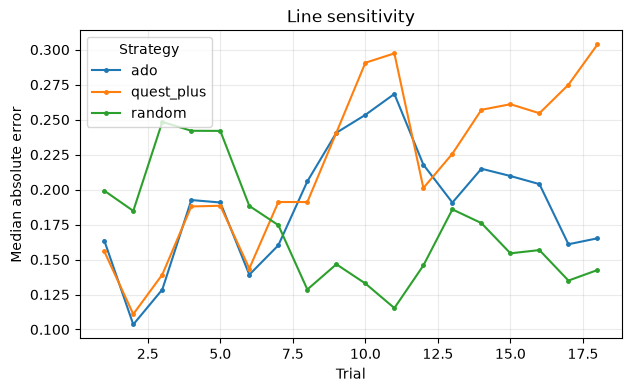

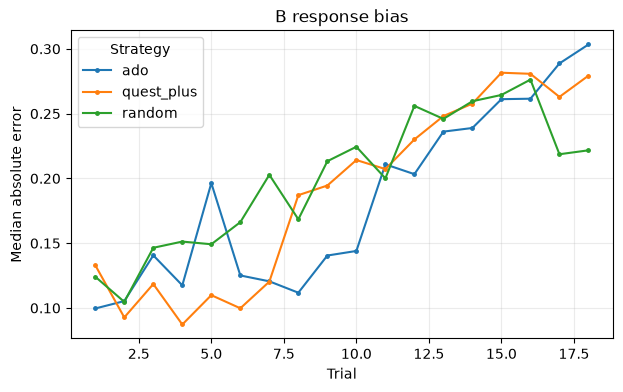

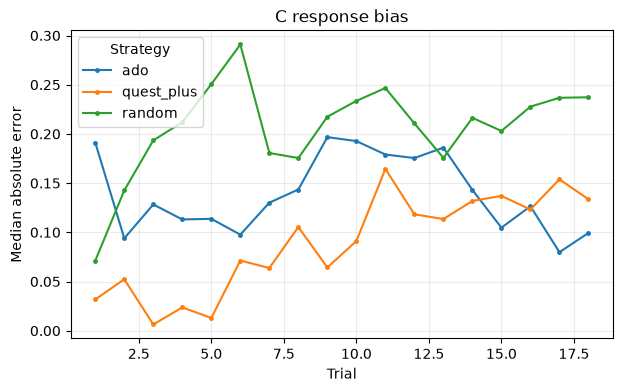

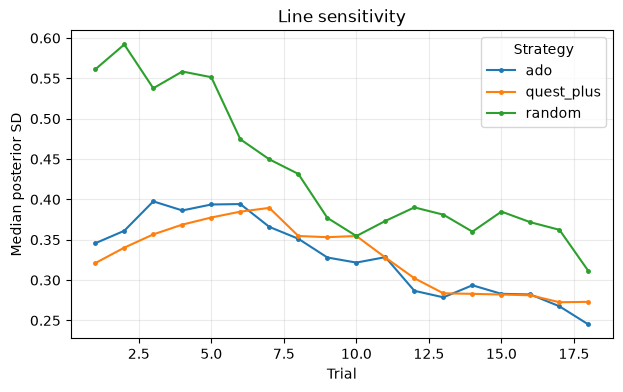

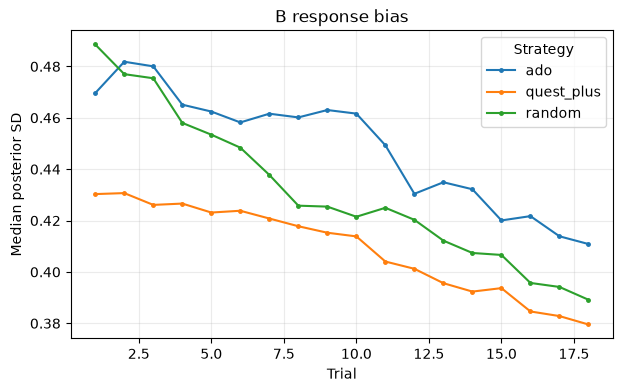

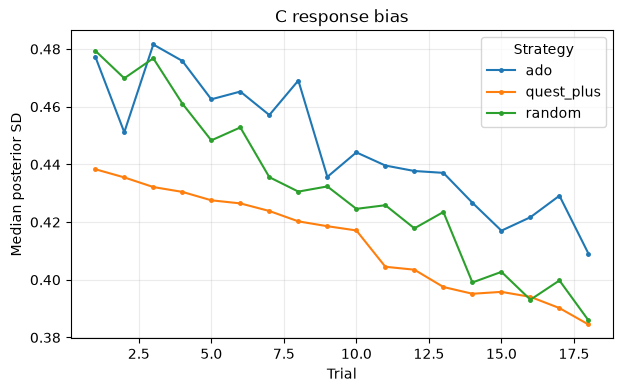

In [9]:
def plot_metric_by_parameter(data, metric, ylabel, selected_parameters):
    for parameter_name in selected_parameters:
        plot_data = data[data["parameter"] == parameter_name]
        if plot_data.empty:
            continue
        label = plot_data["parameter_label"].iloc[0]
        fig, ax = plt.subplots(figsize=(7, 4))
        for strategy, strategy_data in plot_data.groupby("strategy"):
            strategy_data = strategy_data.sort_values("trial_number")
            ax.plot(strategy_data["trial_number"], strategy_data[metric], marker="o", markersize=2.5, label=strategy)
        ax.set_title(label)
        ax.set_xlabel("Trial")
        ax.set_ylabel(ylabel)
        ax.legend(title="Strategy")
        ax.grid(alpha=0.25)
        plt.show()

plot_metric_by_parameter(trajectory, "median_abs_error", "Median absolute error", SELECTED_PARAMETERS)
plot_metric_by_parameter(trajectory, "median_post_sd", "Median posterior SD", SELECTED_PARAMETERS)

## All-parameter table

This compact table is useful when the model has more parameters than are practical to inspect as individual plots.

In [10]:
all_parameter_table = final_summary.pivot_table(
    index=["parameter", "parameter_label", "parameter_scale"],
    columns="strategy",
    values="median_abs_error",
)
display(all_parameter_table)

,,strategy,ado,quest_plus,random
parameter,parameter_label,parameter_scale,,,
bias_b,B response bias,linear,0.303358,0.279312,0.221694
bias_c,C response bias,linear,0.099361,0.133600,0.237210
sensitivity,Line sensitivity,linear,0.165177,0.303701,0.142485


## Interpretation notes

Read this as an audit of the current browser workflow: the task page, jsPsych simulation behavior, Stan/WASM posterior updates, Quest+ posterior updates, and design-selection policy are all in the loop. Stronger adaptive performance should show up as lower final error and faster median error reduction relative to the random baseline. Quest+ uses a discrete parameter grid, while the Stan controller summarizes continuous posterior samples, so compare the trajectories as workflow evidence rather than as a definitive efficiency result. Remaining caveats are model-specific, grid-specific, and simulation-size-specific; this notebook should be rerun with broader profiles before making efficiency claims.